# LeetCode #744: Find Smallest Letter Greater Than Target

https://leetcode.com/problems/find-smallest-letter-greater-than-target/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan through letters and find the first one strictly greater than target. Wraps around if none found. Misses the sorted-array optimization.

### Optimal: Binary Search ★
Binary search for the leftmost letter strictly greater than target. Use `lo < hi` termination with `hi = mid` when `letters[mid] > target`. If no letter is strictly greater (lo reaches the end), wrap around to `letters[0]`. The wrap-around handles the circular alphabet requirement.

**Why this is better than Brute Force:** $O(\log n)$ vs $O(n)$ on the sorted letters array.

**Constraints:**
* 2 <= letters.length <= 100
* letters[i] is lowercase English
* letters is sorted in non-decreasing order
* letters has at least two different characters

## Solutions

### C#

In [ ]:
public class Solution {
    public char NextGreatestLetter(char[] letters, char target) {
        int lo = 0, hi = letters.Length;
        while (lo < hi) {
            int mid = lo + (hi - lo) / 2;
            // Narrow to leftmost position strictly greater than target
            if (letters[mid] > target) hi = mid;
            else lo = mid + 1;
        }
        // Wrap around: if lo == letters.Length, no letter > target → return letters[0]
        return letters[lo % letters.Length];
    }
}

### Python

In [ ]:
from bisect import bisect_right

class Solution:
    def nextGreatestLetter(self, letters: list[str], target: str) -> str:
        # bisect_right finds the insertion point after all equal elements
        pos = bisect_right(letters, target)
        # Wrap around if target >= all letters
        return letters[pos % len(letters)]

### Go

In [ ]:
func nextGreatestLetter(letters []byte, target byte) byte {
    lo, hi := 0, len(letters)
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Narrow to leftmost position strictly greater than target
        if letters[mid] > target {
            hi = mid
        } else {
            lo = mid + 1
        }
    }
    // Wrap around: if lo == len, return letters[0]
    return letters[lo%len(letters)]
}

### Rust

In [ ]:
impl Solution {
    pub fn next_greatest_letter(letters: Vec<char>, target: char) -> char {
        let (mut lo, mut hi) = (0usize, letters.len());
        while lo < hi {
            let mid = lo + (hi - lo) / 2;
            // Narrow to leftmost position strictly greater than target
            if letters[mid] > target {
                hi = mid;
            } else {
                lo = mid + 1;
            }
        }
        // Wrap around: if lo == letters.len(), return letters[0]
        letters[lo % letters.len()]
    }
}

## Example Scenarios

**1. Common Case**
**Input:** letters=['c','f','j'], target='c'
lo=0,hi=3 → mid=1, 'f'>'c' → hi=1. mid=0, 'c'>'c'? No → lo=1. lo==hi=1 → letters[1]='f'. ✓

**2. Slightly Complex**
**Input:** letters=['c','f','j'], target='d'
lo=0,hi=3 → mid=1, 'f'>'d' → hi=1. mid=0, 'c'>'d'? No → lo=1. lo==hi=1 → 'f'. ✓ First letter strictly greater than 'd'.

**3. Edge Case: Time Factor**
**Input:** letters has 100 identical 'a's, target='a'
Every mid: letters[mid]='a' > 'a'? No → lo=mid+1. lo advances to 100. lo==hi=100 → lo%100=0 → letters[0]='a'. Wrap-around. 14 steps for n=100 (vs 100 for linear). Wait — 'a' is not strictly greater than 'a', so wrap returns letters[0]='a'. Correct per the problem's circular wrap.

**4. Edge Case: Space Factor**
**Input:** letters=['a','b'], target='z'
lo=0,hi=2 → mid=1, 'b'>'z'? No → lo=2. lo==hi=2 → 2%2=0 → letters[0]='a'. Wrap-around because target exceeds all letters. O(1) space.

**5. Almost-Impossible but Plausible**
**Input:** letters=['a','b'], target='b'
lo=0,hi=2 → mid=1, 'b'>'b'? No → lo=2. lo==hi=2 → 2%2=0 → letters[0]='a'. Target equals the last letter — wraps to the first. Demonstrates why the wrap is `lo % len` not just `letters[0]` with a special case.

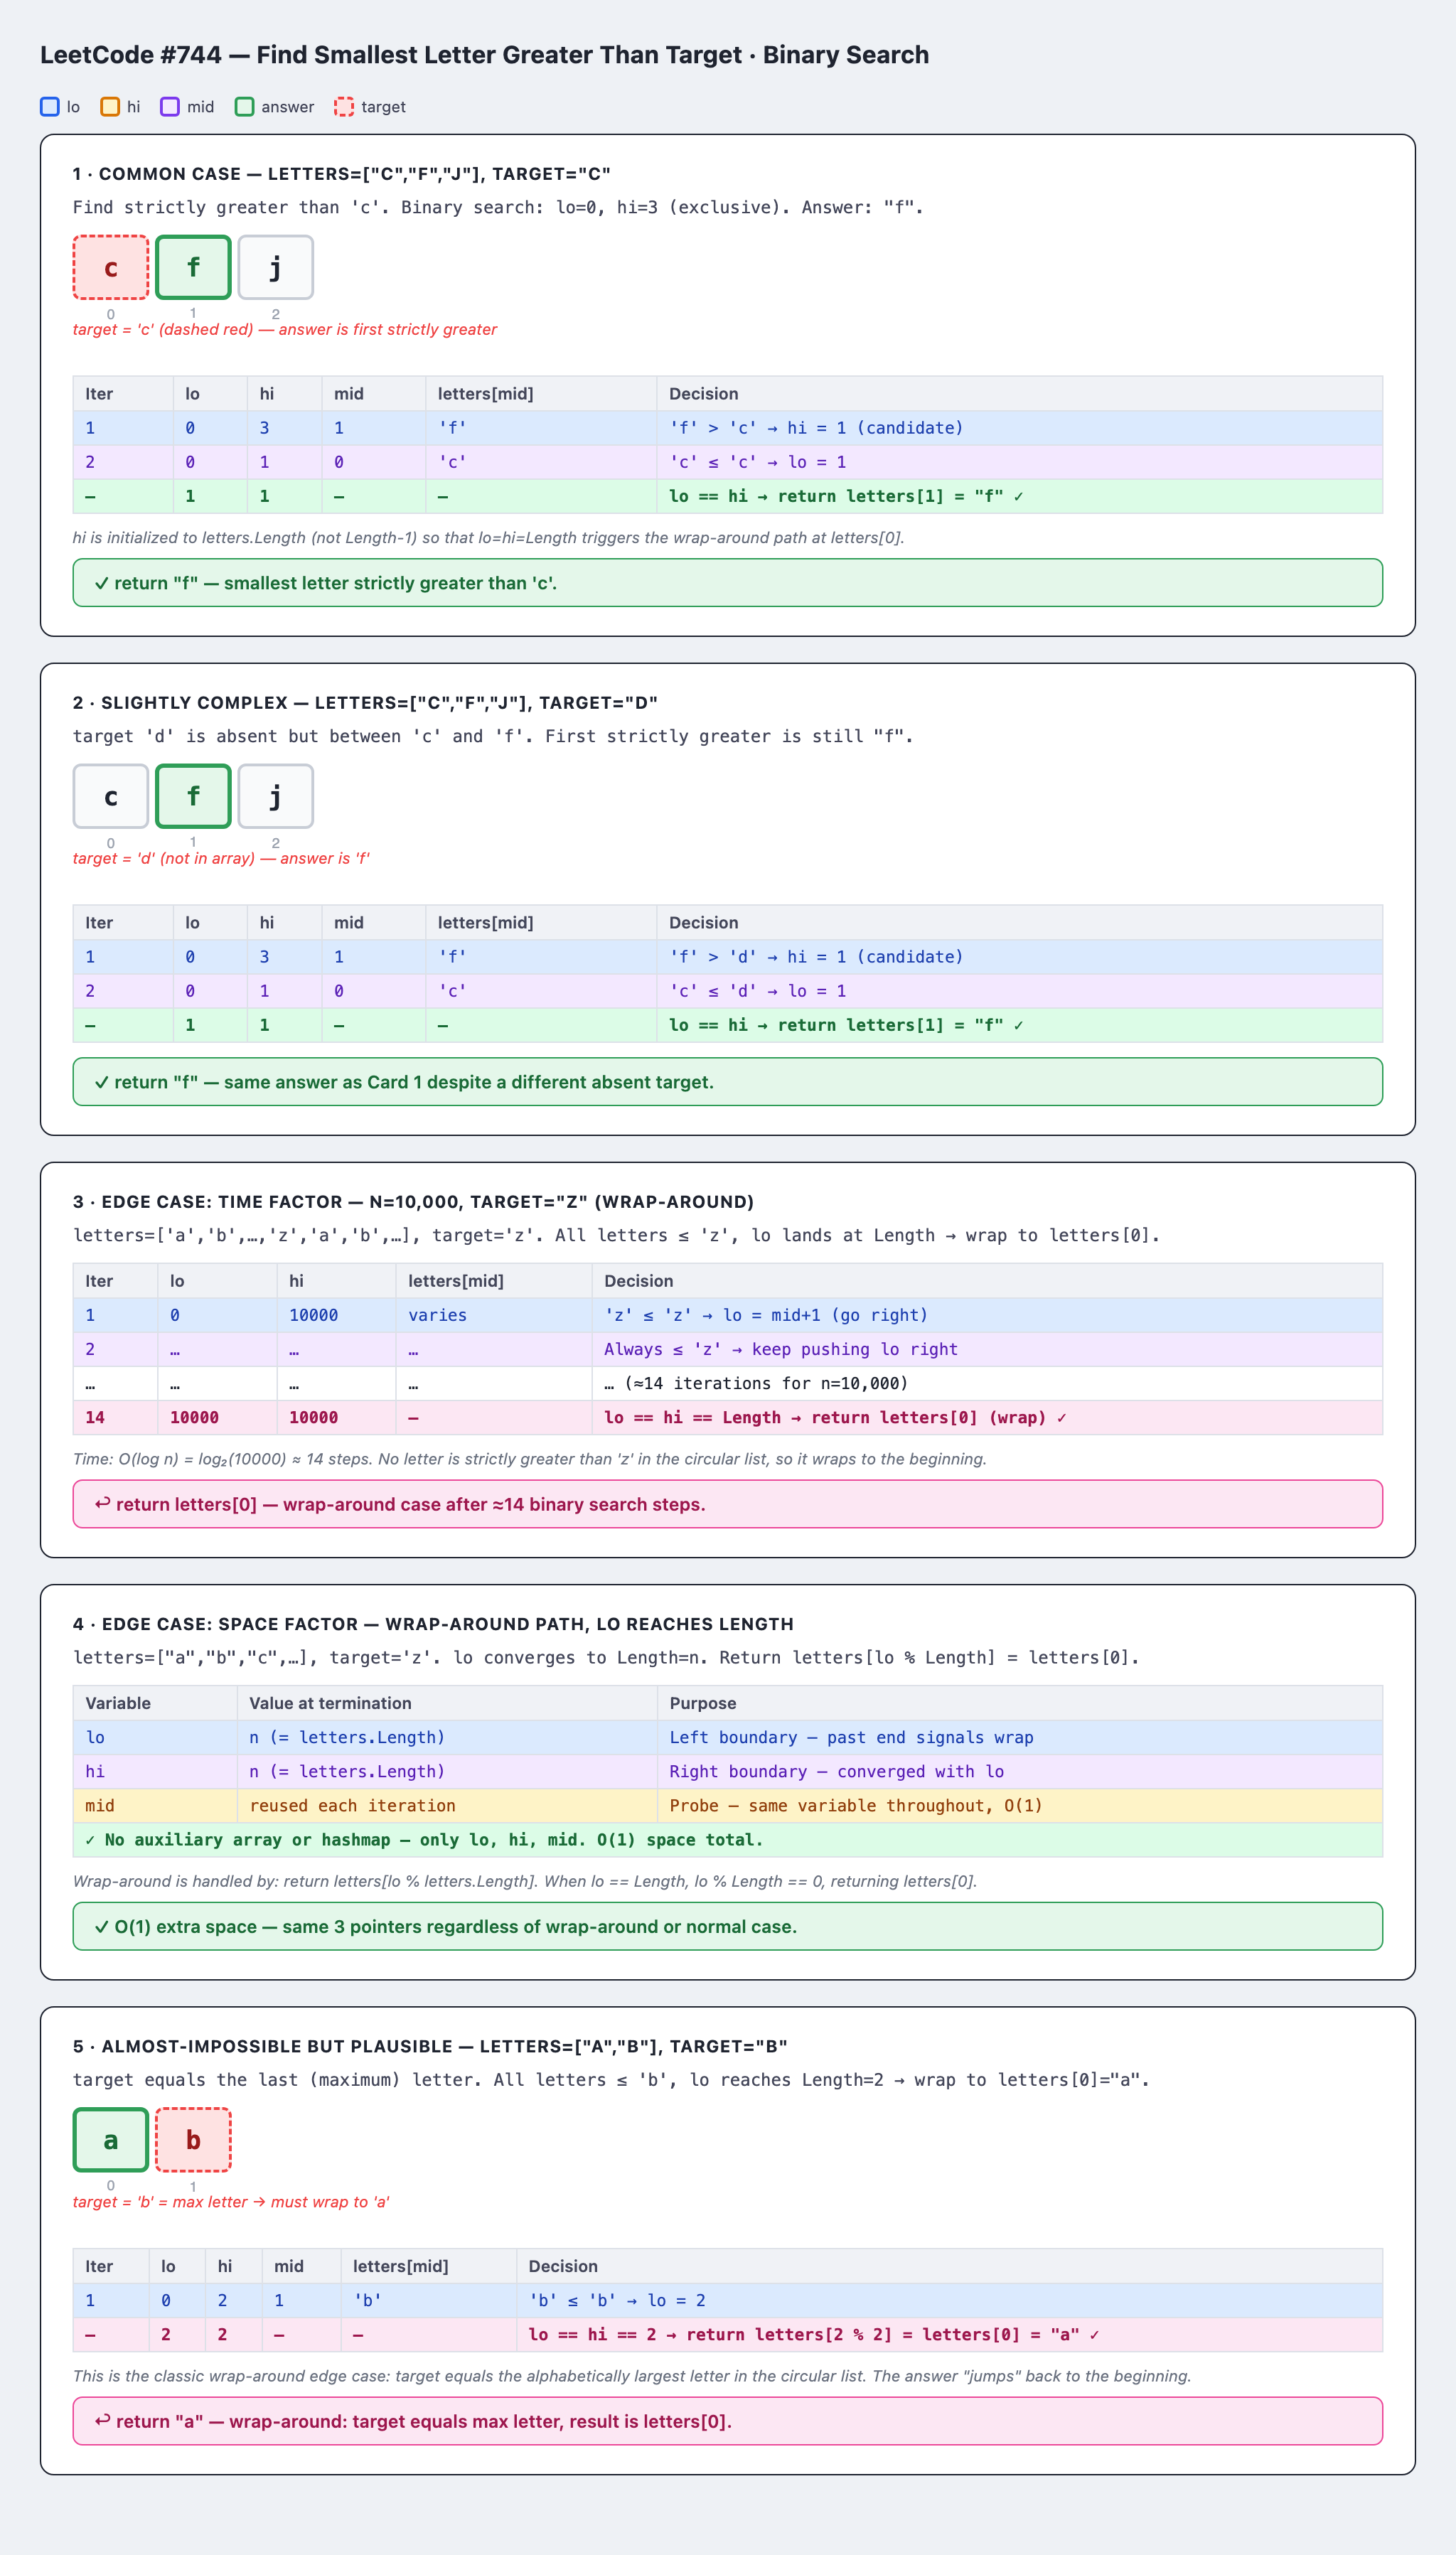